# Comparación final consolidada

Este notebook compara el block bootstrap condicionado, CVAE, normalizing flow y GAN sobre las mismas dimensiones del evaluador común. Mantiene separadas cuatro preguntas: fidelidad generativa, riesgo sobre el test agregado, riesgo bajo el último estado disponible y utilidad downstream al mezclar datos reales y sintéticos. No deben reducirse a una única cifra.

> **Estado de los artefactos:** la fidelidad, el riesgo agregado y el experimento downstream ya se han regenerado con el bootstrap condicionado seleccionado en validación (bloques de 12 pasos y 128 vecinos). Para fidelidad y riesgo se usan 20 escenarios para cada una de las 1.826 condiciones de test; en downstream, los cuatro métodos reciben condiciones pertenecientes exclusivamente a train. El análisis del último estado solo incluye los tres modelos neuronales.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
OUTPUT_DIR = ROOT / 'outputs/final_comparison'
RUN_BUILD = True  # Regenera el baseline estructurado y todas las tablas.
print('Raíz:', ROOT.name)


Raíz: Taller_Generativos


## 1. Contrato de comparación

Las doce dimensiones conservan su unidad y dirección natural. Se declara un ganador por métrica, pero no un ganador global: sumar rangos implicaría decidir de forma arbitraria cuánto vale la calibración frente a la fidelidad temporal, la dependencia de cola o la diversidad.

In [2]:
if RUN_BUILD:
    subprocess.run(
        [sys.executable, str(ROOT / 'scripts/build_final_comparison.py')],
        cwd=ROOT, check=True,
    )
required = [
    OUTPUT_DIR / 'model_quality.csv',
    OUTPUT_DIR / 'rankings_by_dimension.csv',
    OUTPUT_DIR / 'test_portfolio_risk.csv',
    OUTPUT_DIR / 'latest_condition_risk.csv',
    OUTPUT_DIR / 'downstream_comparison.csv',
    OUTPUT_DIR / 'downstream_selected_by_validation.csv',
]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f'Faltan artefactos; activa RUN_BUILD: {missing}')
print('Comparación consolidada disponible en', OUTPUT_DIR.relative_to(ROOT))


Comparación final -> /Users/higiniopaternaortiz/Master_BME/Taller_Generativos/outputs/final_comparison
Bootstrap estructurado -> /Users/higiniopaternaortiz/Master_BME/Taller_Generativos/outputs/block_bootstrap_best/metadata.json
Dimensiones comparadas: 12; score global: no
Comparación consolidada disponible en outputs/final_comparison


In [3]:
quality = pd.read_csv(OUTPUT_DIR / 'model_quality.csv')
rankings = pd.read_csv(OUTPUT_DIR / 'rankings_by_dimension.csv')
test_risk = pd.read_csv(OUTPUT_DIR / 'test_portfolio_risk.csv')
latest_risk = pd.read_csv(OUTPUT_DIR / 'latest_condition_risk.csv')
downstream = pd.read_csv(OUTPUT_DIR / 'downstream_comparison.csv')
downstream_selected = pd.read_csv(OUTPUT_DIR / 'downstream_selected_by_validation.csv')
report = json.loads((OUTPUT_DIR / 'final_comparison.json').read_text(encoding='utf-8'))
display(rankings[['dimension', 'winner', 'winner_value', 'ranking']])


,dimension,winner,winner_value,ranking
0,Fidelidad marginal,block_bootstrap,0.106321,block_bootstrap > cvae > normalizing_flow > co...
1,Persistencia de volatilidad,normalizing_flow,0.049070,normalizing_flow > block_bootstrap > cvae > co...
2,Correlación en estrés,block_bootstrap,0.038390,block_bootstrap > cvae > normalizing_flow > co...
3,Dependencia de cola,block_bootstrap,0.039394,block_bootstrap > cvae > normalizing_flow > co...
4,Distribución del retorno final,normalizing_flow,0.333210,normalizing_flow > cvae > block_bootstrap > co...
5,Volatilidad realizada,cvae,0.316329,cvae > normalizing_flow > block_bootstrap > co...
6,Drawdown,normalizing_flow,0.161645,normalizing_flow > cvae > block_bootstrap > co...
7,Cobertura VaR 95 %,normalizing_flow,0.126342,normalizing_flow > block_bootstrap > cvae > co...
8,Cobertura VaR 99 %,normalizing_flow,0.124173,normalizing_flow > block_bootstrap > cvae > co...
9,Cobertura de la referencia,conditional_gan,0.949617,conditional_gan > cvae > block_bootstrap > nor...


## 2. Utilidad downstream de los datos sintéticos

Esta vista utiliza exactamente la misma MLP para predecir el máximo drawdown a 30 días de la cartera 60/40. Solo cambia la cantidad y fuente de sintéticos añadidos al train; validación y test permanecen reales. Las líneas de test son descriptivas. Para decidir una proporción sin leakage se usa exclusivamente el MAE de validación.

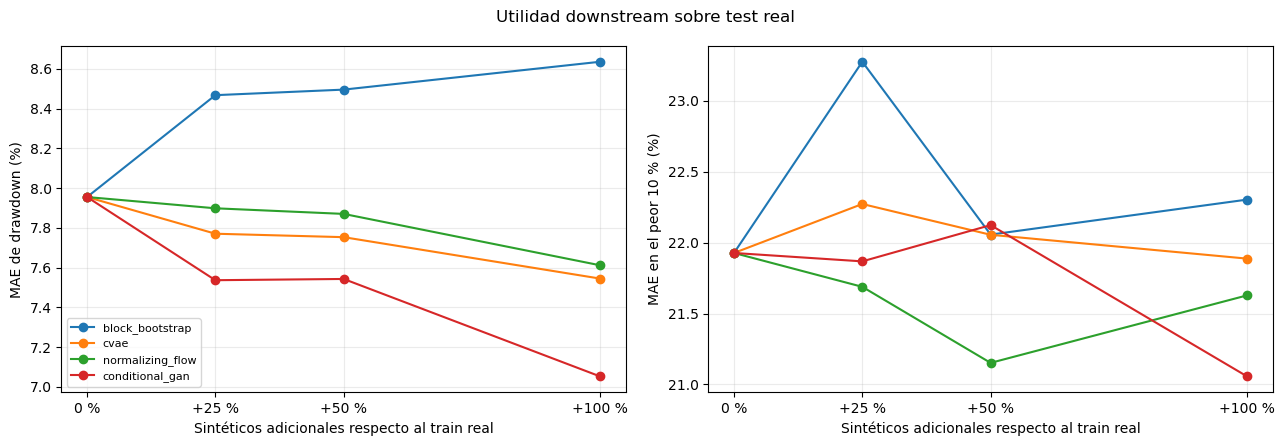

,model,validation_selected_dataset,validation_selected_ratio,validation_selected_mae,validation_selected_test_mae,validation_selected_test_r2,test_descriptive_best_dataset,test_descriptive_best_mae,test_descriptive_improvement_vs_real_only
0,block_bootstrap,real_plus_25pct,0.25,4.599,8.468,-0.696,real_only,7.955,0.000
1,cvae,real_plus_25pct,0.25,4.703,7.770,-0.454,real_plus_100pct,7.544,5.163
2,normalizing_flow,real_only,0.00,4.752,7.955,-0.467,real_plus_100pct,7.611,4.321
3,conditional_gan,real_only,0.00,4.752,7.955,-0.467,real_plus_100pct,7.052,11.355


In [4]:
model_order = ['block_bootstrap', 'cvae', 'normalizing_flow', 'conditional_gan']
ratio_order = [0.0, 0.25, 0.50, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model_name in model_order:
    rows = downstream.loc[downstream['model'].eq(model_name)].sort_values('additional_synthetic_ratio')
    axes[0].plot(ratio_order, 100 * rows['test_mae'], marker='o', label=model_name)
    axes[1].plot(ratio_order, 100 * rows['test_tail_mae_worst_10pct'], marker='o', label=model_name)
for axis, ylabel in zip(axes, ['MAE de drawdown (%)', 'MAE en el peor 10 % (%)']):
    axis.set_xticks(ratio_order, ['0 %', '+25 %', '+50 %', '+100 %'])
    axis.set_xlabel('Sintéticos adicionales respecto al train real')
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)
axes[0].legend(fontsize=8)
fig.suptitle('Utilidad downstream sobre test real')
fig.tight_layout()
plt.show()

selected_display = downstream_selected.copy()
for column in ['validation_selected_mae', 'validation_selected_test_mae', 'test_descriptive_best_mae']:
    selected_display[column] *= 100
selected_display['test_descriptive_improvement_vs_real_only'] *= 100
display(selected_display.round(3))


### Interpretación downstream

Todas las filas proceden ya del mismo experimento regenerado. La selección basada únicamente en validación elige un 25 % de sintéticos para el bootstrap condicionado y el CVAE, mientras que mantiene `real_only` para flow y GAN. En el bootstrap, esa mejora de validación no se traslada al test: el MAE pasa de 7,955 a 8,468 puntos porcentuales, el `R²` cae de −0,467 a −0,696 y ninguna mezcla sintética supera descriptivamente a `real_only`.

En CVAE, la mezcla seleccionada reduce modestamente el MAE de test de 7,955 a 7,770, aunque mantiene `R² < 0` y empeora ligeramente el MAE de la peor decila. Las mejoras máximas observadas únicamente en test —5,163 % para CVAE, 4,321 % para flow y 11,355 % para GAN respecto a `real_only`— corresponden a mezclas no seleccionadas por validación y son solo descriptivas. La comparación debe seguir separando MAE global, error de cola y `R²`.

## 3. Fidelidad, calibración y diversidad

El mapa muestra rangos, no distancias: un 1 identifica el mejor valor de esa fila. La tabla numérica sigue siendo la fuente para valorar si dos posiciones están realmente separadas.

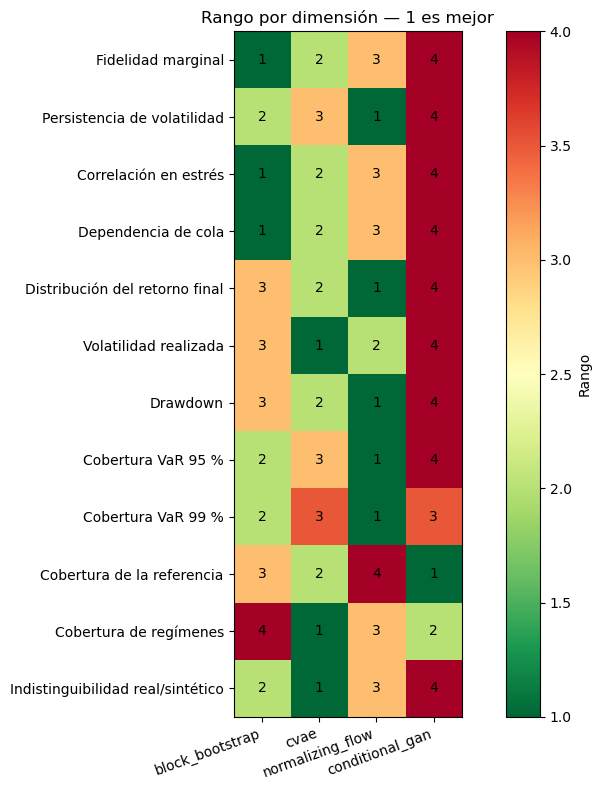

In [5]:
metric_labels = dict(zip(rankings['metric'], rankings['dimension']))
rank_matrix = pd.DataFrame(index=rankings['metric'], columns=quality['model'], dtype=float)
for _, definition in rankings.iterrows():
    values = quality.set_index('model')[definition['metric']]
    rank_matrix.loc[definition['metric']] = values.rank(ascending=bool(definition['lower_is_better']))
rank_matrix.index = [metric_labels[name] for name in rank_matrix.index]
fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(rank_matrix.astype(float), cmap='RdYlGn_r', vmin=1, vmax=len(quality))
ax.set_xticks(range(len(rank_matrix.columns)), rank_matrix.columns, rotation=20, ha='right')
ax.set_yticks(range(len(rank_matrix.index)), rank_matrix.index)
for row in range(len(rank_matrix.index)):
    for column in range(len(rank_matrix.columns)):
        ax.text(column, row, int(rank_matrix.iloc[row, column]), ha='center', va='center')
ax.set_title('Rango por dimensión — 1 es mejor')
fig.colorbar(image, ax=ax, label='Rango')
plt.tight_layout()
plt.show()


In [6]:
display(quality[[
    'model', 'marginal_normalized_w1_mean',
    'absolute_return_acf_rmse_mean', 'stress_correlation_absolute_error',
    'lower_tail_dependence_absolute_error',
    'maximum_drawdown_normalized_w1_mean',
    'portfolio_coverage_error_95', 'portfolio_coverage_error_99',
    'reference_coverage_fraction', 'regime_total_variation_distance',
    'discriminator_accuracy_mean',
]].round(4))


,model,marginal_normalized_w1_mean,absolute_return_acf_rmse_mean,stress_correlation_absolute_error,lower_tail_dependence_absolute_error,maximum_drawdown_normalized_w1_mean,portfolio_coverage_error_95,portfolio_coverage_error_99,reference_coverage_fraction,regime_total_variation_distance,discriminator_accuracy_mean
0,block_bootstrap,0.1063,0.0534,0.0384,0.0394,0.3492,0.1559,0.1543,0.9463,0.2945,0.7920
1,cvae,0.1106,0.0604,0.0490,0.1646,0.2120,0.1592,0.1674,0.9480,0.1395,0.7445
2,normalizing_flow,0.2031,0.0491,0.1149,0.2465,0.1616,0.1263,0.1242,0.9321,0.2595,0.9781
3,conditional_gan,0.2515,0.2124,0.5179,0.4547,0.6218,0.2381,0.1674,0.9496,0.2360,1.0000


## 4. Aplicación de cartera fuera de muestra

La distribución histórica de test es la referencia descriptiva. Los errores de VaR/ES agregados miden cercanía a esa distribución; la cobertura condicional se evalúa por separado y es más exigente. Las ventanas de test se solapan, por lo que no representan 1.826 episodios independientes.

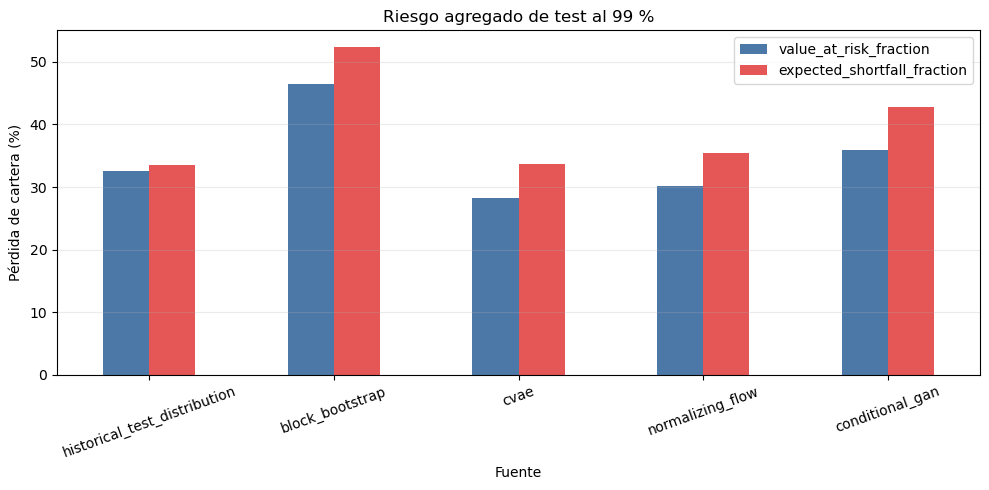

,value_at_risk_fraction,expected_shortfall_fraction,var_absolute_error_vs_historical,es_absolute_error_vs_historical
scenario_set,,,,
historical_test_distribution,0.3248,0.3352,0.0000,0.0000
block_bootstrap,0.4642,0.5242,0.1394,0.1890
cvae,0.2832,0.3369,0.0417,0.0018
normalizing_flow,0.3014,0.3537,0.0234,0.0185
conditional_gan,0.3589,0.4279,0.0341,0.0928


In [7]:
risk_99 = test_risk[test_risk['confidence_level'].eq(0.99)].copy()
risk_99 = risk_99.set_index('scenario_set')
plot = risk_99[['value_at_risk_fraction', 'expected_shortfall_fraction']] * 100
ax = plot.plot.bar(figsize=(10, 5), color=['#4C78A8', '#E45756'])
ax.set(title='Riesgo agregado de test al 99 %', ylabel='Pérdida de cartera (%)', xlabel='Fuente')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
display(risk_99[[
    'value_at_risk_fraction', 'expected_shortfall_fraction',
    'var_absolute_error_vs_historical', 'es_absolute_error_vs_historical',
]].round(4))


## 5. Último estado disponible

La generación de 100.000 escenarios reduce el ruido de Monte Carlo para una sola condición. Compararla con el test agregado sirve como contraste de régimen dentro de cada modelo, no como validación temporal adicional.

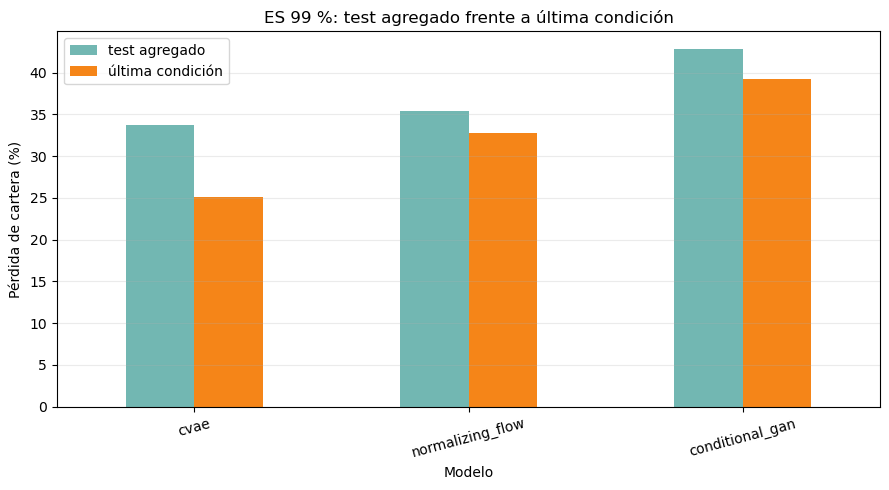

,value_at_risk_fraction,expected_shortfall_fraction,var_change_vs_aggregated_test,es_change_vs_aggregated_test
scenario_set,,,,
cvae,0.2147,0.2507,-0.0685,-0.0863
normalizing_flow,0.2790,0.3275,-0.0224,-0.0263
conditional_gan,0.3271,0.3926,-0.0318,-0.0353


In [8]:
latest_99 = latest_risk[latest_risk['confidence_level'].eq(0.99)].set_index('scenario_set')
test_99_models = test_risk[
    test_risk['confidence_level'].eq(0.99)
    & test_risk['scenario_set'].isin(latest_99.index)
].set_index('scenario_set')
comparison = pd.DataFrame({
    'test agregado': test_99_models['expected_shortfall_fraction'],
    'última condición': latest_99['expected_shortfall_fraction'],
}) * 100
ax = comparison.plot.bar(figsize=(9, 5), color=['#72B7B2', '#F58518'])
ax.set(title='ES 99 %: test agregado frente a última condición', ylabel='Pérdida de cartera (%)', xlabel='Modelo')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
display(latest_99[[
    'value_at_risk_fraction', 'expected_shortfall_fraction',
    'var_change_vs_aggregated_test', 'es_change_vs_aggregated_test',
]].round(4))


## 6. Conclusiones defendibles

El bootstrap condicionado ofrece la mejor fidelidad marginal (0,1063), correlación en estrés (error 0,0384) y dependencia de cola (error 0,0394). También queda segundo en persistencia de volatilidad, pero reproduce peor la distribución de trayectorias y los regímenes: su error normalizado de drawdown es 0,3492 y su distancia de regímenes, 0,2945. En la cartera 60/40 es claramente conservador al 99 %: estima VaR/ES de 46,42 %/52,42 %, frente a 32,48 %/33,52 % en el test histórico.

El flow lidera persistencia, retorno final, drawdown y cobertura condicional, y aproxima mejor la VaR agregada al 99 % (error 2,34 puntos porcentuales). El CVAE lidera volatilidad realizada, cobertura de regímenes e indistinguibilidad, y aproxima mejor el ES agregado al 99 % (error 0,18 puntos). La GAN alcanza la mayor cobertura de la referencia, pero queda por detrás en la mayoría de medidas de fidelidad.

No hay un campeón global: cada método resuelve mejor objetivos distintos. En downstream, el bootstrap condicionado no aporta una mejora fuera de muestra: validación selecciona `+25 %`, pero esta mezcla empeora MAE, cola y `R²` en test. Solo el 25 % de CVAE transfiere una mejora modesta de MAE tras la selección por validación; todos los `R²` seleccionados siguen siendo negativos. El contraste del último estado muestra menor VaR/ES que el test agregado en los tres modelos neuronales, especialmente en CVAE, pero representa una única condición y no una validación temporal adicional.